In [1]:
"""
10-model comparison — reproduces report Table 4-1 / section 4.2 "Overall Models
Performance"


  STAGE 1 : run all 10 models once, single 80/20 stratified split
  STAGE 2 : 7 of those 10 models came out biased toward PD (TN < 2 —
                      i.e. they barely ever predicted "healthy control" correctly)
                      Re-run just those 7 with a stricter threshold search
                      (starts at 0.40 instead of 0.25) and class_weight tuning
                      added to the grid
  STAGE 3 : for every model, keep whichever version — original or
                      fixed — has the higher test F1. This "best_of" dict is
                      what Table 4-1 reports, and what the repeated-CV step
                      (section 4.4) is built on.
"""

import warnings
import os
from functools import partial

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif, VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import sys
sys.path.append("..")  # so config.py (in the repo root) is importable from notebooks/
from config import SUBJECTS, OUTPUT_DIR, FEATURE_MATRIX_PATH, PARTICIPANTS_TSV, MODELS_DIR, ALL_RESULTS_PKL, FIGURES_DIR

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False


def load_data():
    feat_df = pd.read_csv(FEATURE_MATRIX_PATH)
    subject_list = feat_df["Subject"].tolist()
    X = feat_df.drop(columns=["Subject"]).values

    participants_df = pd.read_csv(PARTICIPANTS_TSV, sep="\t")
    label_map = {"Control": 0, "PD-NC": 1, "PD-MCI": 1}
    y = np.array([
        label_map[participants_df.loc[participants_df["participant_id"] == s, "group"].values[0]]
        for s in subject_list
    ])
    return X, y


def base_steps(with_pca=True):
    mi = partial(mutual_info_classif, random_state=RANDOM_STATE)
    steps = [
        ("var", VarianceThreshold(0.01)),
        ("scale", RobustScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("select", SelectKBest(mi)),
    ]
    if with_pca:
        steps.append(("pca", PCA(random_state=RANDOM_STATE)))
    return steps


def find_best_threshold(model, X_tr, y_tr, cv, t_start=0.25):
    """Fit each CV fold ONCE, cache out-of-fold probabilities, then sweep
    thresholds over the cached arrays. Mathematically identical to refitting
    per threshold, but ~25x fewer pipeline fits (5 instead of ~130 per model)."""
    fold_probs, fold_ys = [], []
    for tr_idx, val_idx in cv.split(X_tr, y_tr):
        model.fit(X_tr[tr_idx], y_tr[tr_idx])
        fold_probs.append(model.predict_proba(X_tr[val_idx])[:, 1])
        fold_ys.append(y_tr[val_idx])

    best_t, best_f1 = 0.5, -1
    for t in np.arange(t_start, 0.76, 0.02):
        fold_f1s = [f1_score(y_val, (prob >= t).astype(int), zero_division=0)
                    for prob, y_val in zip(fold_probs, fold_ys)]
        mean_f1 = np.mean(fold_f1s)
        if mean_f1 > best_f1:
            best_f1, best_t = mean_f1, t
    return best_t


def evaluate(pipeline, param_grid, X_train, y_train, X_test, y_test, cv5, t_start=0.25):
    grid = GridSearchCV(pipeline, param_grid, scoring="f1", cv=cv5, n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    best_t = find_best_threshold(best_model, X_train, y_train, cv5, t_start=t_start)

    best_model.fit(X_train, y_train)
    y_prob = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= best_t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        "cv_f1": round(grid.best_score_, 4),
        "test_f1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "test_auc": round(roc_auc_score(y_test, y_prob), 4),
        "test_prec": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "test_rec": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "test_acc": round(accuracy_score(y_test, y_pred), 4),
        "threshold": round(best_t, 3),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "best_params": grid.best_params_,
        "_model": best_model, "_yprob": y_prob, "_ypred": y_pred,
    }


# STAGE 1 — original 10-model comparison

def stage1_original_models(spw):
    models = {
        "LogisticRegression": (
            ImbPipeline(base_steps() + [
                ("model", LogisticRegression(penalty="elasticnet", solver="saga", max_iter=5000,
                                              class_weight="balanced", random_state=RANDOM_STATE))
            ]),
            {"select__k": [15, 25, 40], "pca__n_components": [0.85, 0.90, 0.95],
             "model__C": [0.001, 0.01, 0.1], "model__l1_ratio": [0.3, 0.5, 0.7]},
        ),
        "RidgeClassifier": (
            ImbPipeline(base_steps() + [
                ("model", CalibratedClassifierCV(RidgeClassifier(class_weight="balanced"), cv=3))
            ]),
            {"select__k": [15, 25, 40], "pca__n_components": [0.85, 0.90, 0.95],
             "model__estimator__alpha": [0.1, 1.0, 10.0, 50.0]},
        ),
        "SVM_RBF": (
            ImbPipeline(base_steps() + [
                ("model", SVC(probability=True, kernel="rbf", class_weight="balanced"))
            ]),
            {"select__k": [15, 25, 40], "pca__n_components": [0.85, 0.90, 0.95],
             "model__C": [0.1, 1, 5, 10], "model__gamma": ["scale", 0.01, 0.001]},
        ),
        "SVM_Linear": (
            ImbPipeline(base_steps() + [
                ("model", SVC(probability=True, kernel="linear", class_weight="balanced"))
            ]),
            {"select__k": [15, 25, 40], "pca__n_components": [0.85, 0.90, 0.95],
             "model__C": [0.001, 0.01, 0.1, 1]},
        ),
        "RandomForest": (
            ImbPipeline(base_steps(with_pca=False) + [
                ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
            ]),
            {"select__k": [15, 25, 40], "model__n_estimators": [100, 200, 300],
             "model__max_depth": [4, 6, 8, None], "model__min_samples_leaf": [1, 2, 3]},
        ),
        "ExtraTrees": (
            ImbPipeline(base_steps(with_pca=False) + [
                ("model", ExtraTreesClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
            ]),
            {"select__k": [15, 25, 40], "model__n_estimators": [100, 200, 300],
             "model__max_depth": [4, 6, 8, None], "model__min_samples_leaf": [1, 2, 3]},
        ),
        "GradientBoosting": (
            ImbPipeline(base_steps(with_pca=False) + [
                ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
            ]),
            {"select__k": [15, 25, 40], "model__n_estimators": [100, 200],
             "model__max_depth": [2, 3, 4], "model__learning_rate": [0.05, 0.1],
             "model__subsample": [0.7, 0.9, 1.0]},
        ),
        "KNN": (
            ImbPipeline(base_steps() + [("model", KNeighborsClassifier())]),
            {"select__k": [10, 15, 25, 40], "pca__n_components": [0.85, 0.90, 0.95],
             "model__n_neighbors": [3, 5, 7, 9], "model__weights": ["uniform", "distance"],
             "model__metric": ["euclidean", "manhattan"]},
        ),
    }
    if HAS_XGB:
        models["XGBoost"] = (
            ImbPipeline(base_steps(with_pca=False) + [
                ("model", XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                                         scale_pos_weight=spw, random_state=RANDOM_STATE,
                                         n_jobs=-1, verbosity=0))
            ]),
            {"select__k": [15, 25, 40], "model__n_estimators": [100, 200],
             "model__max_depth": [2, 3, 4], "model__learning_rate": [0.05, 0.1],
             "model__subsample": [0.7, 0.9, 1.0], "model__colsample_bytree": [0.7, 1.0]},
        )
    if HAS_LGB:
        models["LightGBM"] = (
            ImbPipeline(base_steps(with_pca=False) + [
                ("model", lgb.LGBMClassifier(class_weight="balanced", random_state=RANDOM_STATE,
                                              n_jobs=-1, verbose=-1))
            ]),
            {"select__k": [15, 25, 40], "model__n_estimators": [100, 200],
             "model__max_depth": [3, 5, 7], "model__learning_rate": [0.05, 0.1],
             "model__num_leaves": [15, 31]},
        )
    return models


# STAGE 2 — fix pass for the 7 models that came out biased toward PD
# (TN < 2 in stage 1): stricter threshold floor + class_weight tuning

def stage2_fix_models():
    return {
        "LogisticRegression": (
            ImbPipeline(base_steps() + [
                ("model", LogisticRegression(penalty="elasticnet", solver="saga",
                                              max_iter=5000, random_state=RANDOM_STATE))
            ]),
            {"select__k": [15, 25, 40], "pca__n_components": [0.85, 0.90, 0.95],
             "model__C": [0.001, 0.01, 0.1, 1], "model__l1_ratio": [0.3, 0.5, 0.7],
             "model__class_weight": ["balanced", {0: 2, 1: 1}, {0: 3, 1: 1}]},
        ),
        "RidgeClassifier": (
            ImbPipeline(base_steps() + [("model", CalibratedClassifierCV(RidgeClassifier(), cv=3))]),
            {"select__k": [15, 25, 40], "pca__n_components": [0.85, 0.90, 0.95],
             "model__estimator__alpha": [0.01, 0.1, 1.0, 10.0, 50.0],
             "model__estimator__class_weight": ["balanced", {0: 2, 1: 1}, {0: 3, 1: 1}]},
        ),
        "SVM_RBF": (
            ImbPipeline(base_steps() + [("model", SVC(probability=True, kernel="rbf"))]),
            {"select__k": [15, 25, 40], "pca__n_components": [0.85, 0.90, 0.95],
             "model__C": [0.01, 0.1, 1, 5, 10, 50], "model__gamma": ["scale", "auto", 0.01, 0.001],
             "model__class_weight": ["balanced", {0: 2, 1: 1}, {0: 3, 1: 1}]},
        ),
        "SVM_Linear": (
            ImbPipeline(base_steps() + [("model", SVC(probability=True, kernel="linear"))]),
            {"select__k": [15, 25, 40], "pca__n_components": [0.85, 0.90, 0.95],
             "model__C": [0.0001, 0.001, 0.01, 0.1, 1],
             "model__class_weight": ["balanced", {0: 2, 1: 1}, {0: 3, 1: 1}]},
        ),
        "RandomForest": (
            ImbPipeline(base_steps(with_pca=False) + [
                ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
            ]),
            {"select__k": [15, 25, 40], "model__n_estimators": [100, 200, 300],
             "model__max_depth": [3, 4, 6, 8], "model__min_samples_leaf": [2, 3, 4],
             "model__class_weight": ["balanced", "balanced_subsample", {0: 2, 1: 1}, {0: 3, 1: 1}]},
        ),
        "ExtraTrees": (
            ImbPipeline(base_steps(with_pca=False) + [
                ("model", ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1))
            ]),
            {"select__k": [15, 25, 40], "model__n_estimators": [100, 200, 300],
             "model__max_depth": [3, 4, 6, 8], "model__min_samples_leaf": [2, 3, 4],
             "model__class_weight": ["balanced", "balanced_subsample", {0: 2, 1: 1}, {0: 3, 1: 1}]},
        ),
        "GradientBoosting": (
            ImbPipeline(base_steps(with_pca=False) + [
                ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
            ]),
            {"select__k": [15, 25, 40], "model__n_estimators": [50, 100, 200],
             "model__max_depth": [2, 3, 4], "model__learning_rate": [0.01, 0.05, 0.1],
             "model__subsample": [0.6, 0.7, 0.8, 1.0], "model__min_samples_leaf": [2, 3, 4]},
        ),
    }


def run_full_pipeline(X, y):
    """Runs every model, silently re-tunes any that came out biased toward PD
    (TN < 2), and keeps whichever version — original or re-tuned — scores
    higher. Returns just the 10 final chosen models."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    spw = np.sum(y_train == 0) / np.sum(y_train == 1)
    cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    print(f"Train: {X_train.shape}  HC={np.sum(y_train==0)}  PD={np.sum(y_train==1)}")
    print(f"Test : {X_test.shape}   HC={np.sum(y_test==0)}   PD={np.sum(y_test==1)}\n")

    all_results = {}
    for name, (pipeline, grid) in stage1_original_models(spw).items():
        print(f"[stage 1] fitting {name}...", flush=True)
        all_results[name] = evaluate(pipeline, grid, X_train, y_train, X_test, y_test, cv5, t_start=0.25)
        print(f"           F1={all_results[name]['test_f1']:.3f}  TN={all_results[name]['TN']}", flush=True)

    fixed_results = {}
    fix_models = stage2_fix_models()
    for name, (pipeline, grid) in fix_models.items():
        if name not in all_results or all_results[name]["TN"] >= 2:
            continue  # only re-tune what actually needed it
        print(f"[stage 2] re-tuning {name} (was TN={all_results[name]['TN']})...", flush=True)
        fixed_results[name] = evaluate(pipeline, grid, X_train, y_train, X_test, y_test, cv5, t_start=0.40)
        print(f"           F1={fixed_results[name]['test_f1']:.3f}  TN={fixed_results[name]['TN']}", flush=True)

    best_of = {}
    for name in all_results:
        orig = all_results.get(name)
        fixed = fixed_results.get(name)
        best_of[name] = fixed if (fixed is not None and fixed["test_f1"] >= orig["test_f1"]) else orig

    return best_of, y_test


def print_table_4_1(best_of, y_test):
    rows = [{"Model": name, **{k: v for k, v in r.items() if not k.startswith("_")}}
            for name, r in best_of.items()]
    table = pd.DataFrame(rows).sort_values("test_f1", ascending=False).reset_index(drop=True)

    print("=" * 80)
    print("10 CHOSEN MODELS — sorted by Test F1")
    print("=" * 80)
    print(table[["Model", "test_f1", "test_auc", "test_prec", "test_rec",
                 "test_acc", "threshold", "TN", "FP", "FN", "TP"]].to_string())

    best_name = table.iloc[0]["Model"]
    print(f"\nBest model: {best_name}")
    print(classification_report(y_test, best_of[best_name]["_ypred"],
                                 target_names=["HC", "PD"], zero_division=0))
    return table


if __name__ == "__main__":
    X, y = load_data()
    best_of, y_test = run_full_pipeline(X, y)
    print_table_4_1(best_of, y_test)


Train: (44, 6670)  HC=18  PD=26
Test : (11, 6670)   HC=4   PD=7

[stage 1] fitting LogisticRegression...
           F1=0.778  TN=0
[stage 1] fitting RidgeClassifier...
           F1=0.824  TN=1
[stage 1] fitting SVM_RBF...
           F1=0.824  TN=1
[stage 1] fitting SVM_Linear...
           F1=0.824  TN=1
[stage 1] fitting RandomForest...
           F1=0.824  TN=1
[stage 1] fitting ExtraTrees...
           F1=0.824  TN=1
[stage 1] fitting GradientBoosting...
           F1=0.667  TN=1
[stage 1] fitting KNN...
           F1=0.800  TN=2
[stage 1] fitting XGBoost...
           F1=0.750  TN=1
[stage 1] fitting LightGBM...
           F1=0.750  TN=1
[stage 2] re-tuning LogisticRegression (was TN=0)...
           F1=0.857  TN=3
[stage 2] re-tuning RidgeClassifier (was TN=1)...
           F1=0.857  TN=3
[stage 2] re-tuning SVM_RBF (was TN=1)...
           F1=0.778  TN=0
[stage 2] re-tuning SVM_Linear (was TN=1)...
           F1=0.875  TN=2
[stage 2] re-tuning RandomForest (was TN=1)...
        

In [2]:
# Prints the classification report for each of the 10 chosen models

from sklearn.metrics import classification_report
import pandas as pd

rows = [{"Model": name, "test_f1": r["test_f1"]} for name, r in best_of.items()]
order = pd.DataFrame(rows).sort_values("test_f1", ascending=False)["Model"].tolist()

for rank, name in enumerate(order, start=1):
    r = best_of[name]
    print(f"\n#{rank}  {name}")
    print(f"Test F1={r['test_f1']:.4f}  AUC={r['test_auc']:.4f}  Threshold={r['threshold']}")
    print(f"Confusion: TN={r['TN']} FP={r['FP']} FN={r['FN']} TP={r['TP']}")
    print(classification_report(y_test, r["_ypred"], target_names=["HC", "PD"], zero_division=0))
    print("-" * 80)


#1  SVM_Linear
Test F1=0.8750  AUC=0.8571  Threshold=0.4
Confusion: TN=2 FP=2 FN=0 TP=7
              precision    recall  f1-score   support

          HC       1.00      0.50      0.67         4
          PD       0.78      1.00      0.88         7

    accuracy                           0.82        11
   macro avg       0.89      0.75      0.77        11
weighted avg       0.86      0.82      0.80        11

--------------------------------------------------------------------------------

#2  LogisticRegression
Test F1=0.8571  AUC=0.8929  Threshold=0.4
Confusion: TN=3 FP=1 FN=1 TP=6
              precision    recall  f1-score   support

          HC       0.75      0.75      0.75         4
          PD       0.86      0.86      0.86         7

    accuracy                           0.82        11
   macro avg       0.80      0.80      0.80        11
weighted avg       0.82      0.82      0.82        11

-------------------------------------------------------------------------------

In [11]:
# save models
import joblib

results = {
    "best_of": best_of,
    "y_test": y_test,
}

joblib.dump(results, ALL_RESULTS_PKL)

['C:/Users/XPRISTO/Desktop/parkinsons-fmri-classification/models/all_results.pkl']

In [12]:
print(best_of.keys())
print(len(best_of))

dict_keys(['LogisticRegression', 'RidgeClassifier', 'SVM_RBF', 'SVM_Linear', 'RandomForest', 'ExtraTrees', 'GradientBoosting', 'KNN', 'XGBoost', 'LightGBM'])
10


In [2]:
import joblib

results = joblib.load(ALL_RESULTS_PKL)

best_of = results["best_of"]
y_test = results["y_test"]

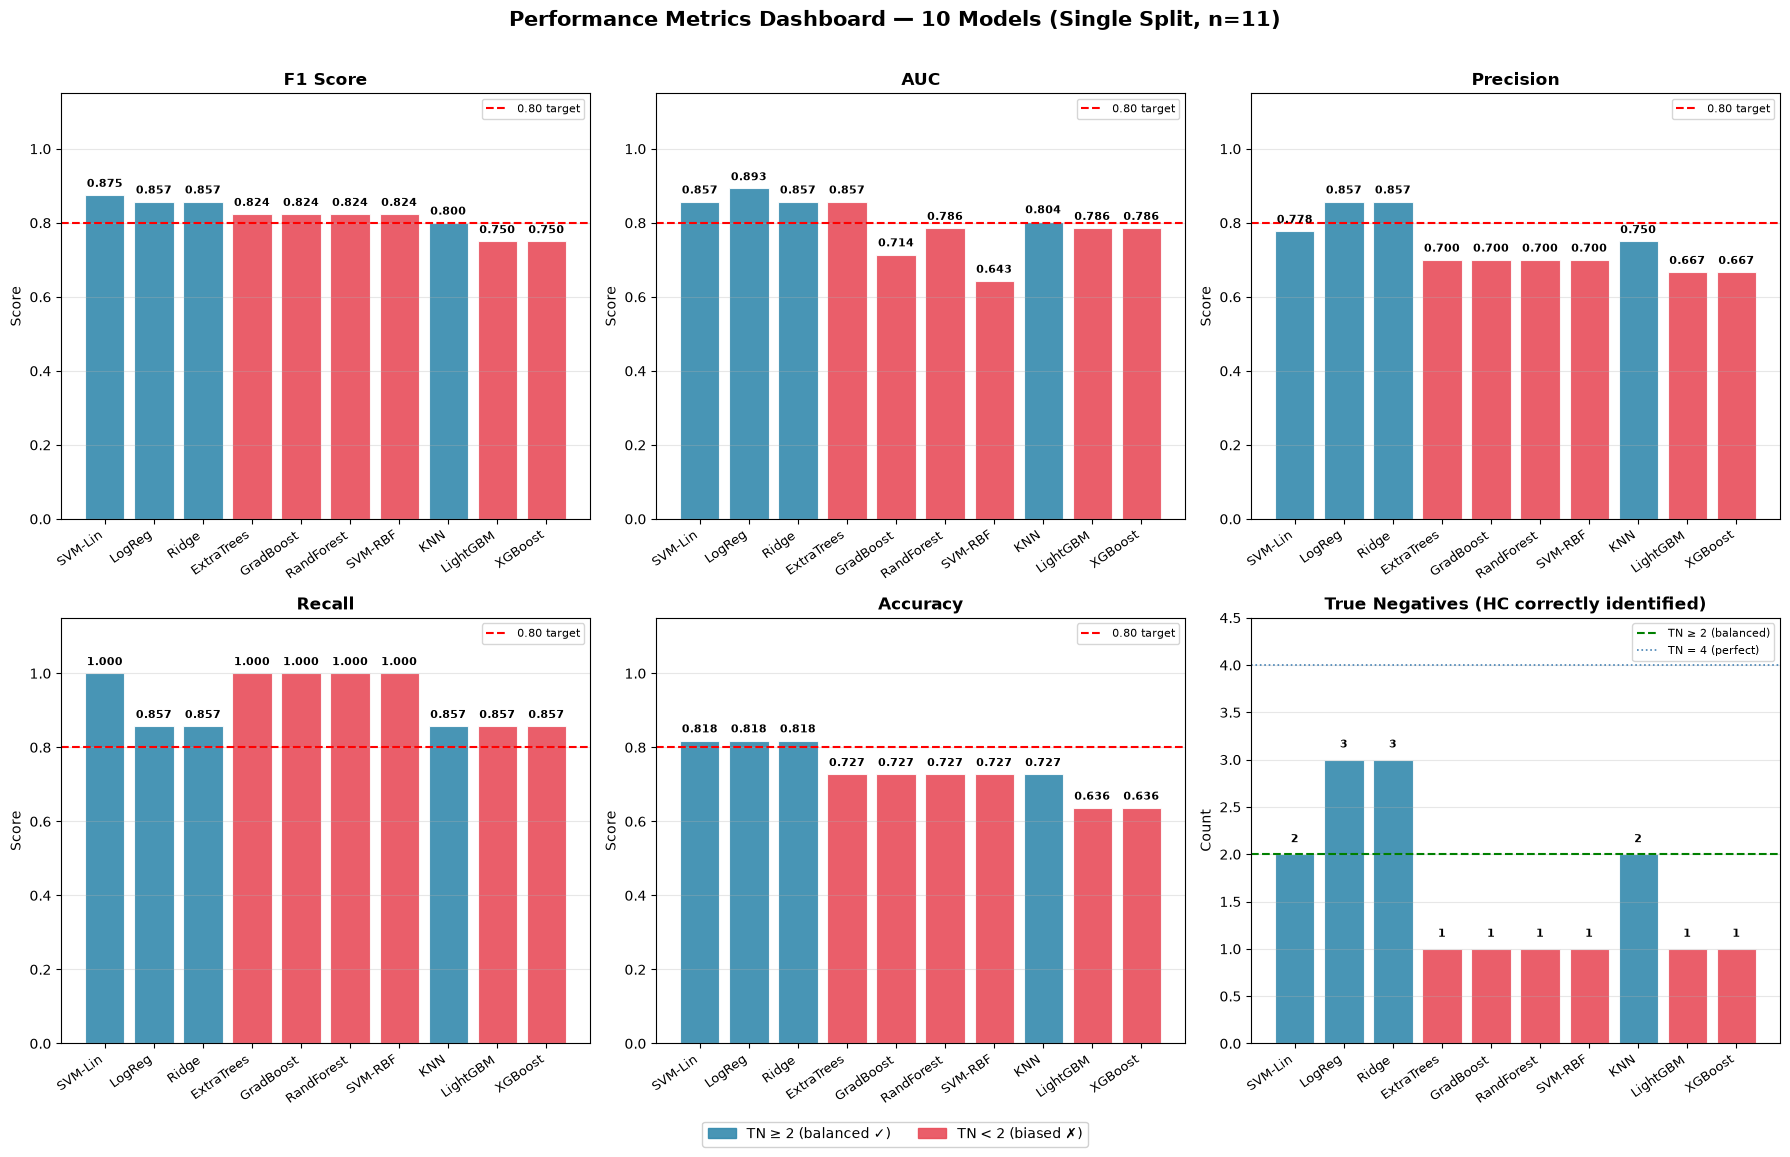

Saved: performance_metrics_dashboard.png


In [4]:
"""
Creates the "Metrics Dashboard — 10 Models (Single Split, n=11)" figure:
6 panels (F1, AUC, Precision, Recall, Accuracy, True Negatives), models
sorted by F1, colored blue if TN >= 2 (balanced) or red if TN < 2 (biased
toward predicting PD)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# Build table from existing best_of dictionary
rows = [
    {"Model": name, **{k: v for k, v in r.items() if not k.startswith("_")}}
    for name, r in best_of.items()
]

table = (
    pd.DataFrame(rows)
    .sort_values("test_f1", ascending=False)
    .reset_index(drop=True)
)


# Model names
models = table["Model"].tolist()

short = [
    "SVM-Lin",
    "LogReg",
    "Ridge",
    "ExtraTrees",
    "GradBoost",
    "RandForest",
    "SVM-RBF",
    "KNN",
    "LightGBM",
    "XGBoost"
][:len(models)]


# Metrics
f1   = table["test_f1"].values
auc  = table["test_auc"].values
prec = table["test_prec"].values
rec  = table["test_rec"].values
acc  = table["test_acc"].values
tn   = table["TN"].values


n = len(models)
x = np.arange(n)


# Colors based on TN
BLUE = "#2E86AB"
RED  = "#E84855"

bar_colors = [
    BLUE if t >= 2 else RED
    for t in tn
]


# Figure 
fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 11)
)

fig.suptitle(
    f"Performance Metrics Dashboard — 10 Models (Single Split, n={11})",
    fontsize=15,
    fontweight="bold",
    y=1.01
)


metrics_data = [
    (f1,   "F1 Score", True),
    (auc,  "AUC", True),
    (prec, "Precision", True),
    (rec,  "Recall", True),
    (acc,  "Accuracy", True),
    (tn,   "True Negatives (HC correctly identified)", False),
]


# Plot panels 
for ax, (values, title, score_metric) in zip(
        axes.flat,
        metrics_data
):

    bars = ax.bar(
        x,
        values,
        color=bar_colors,
        alpha=0.88,
        edgecolor="white",
        linewidth=0.8
    )


    if score_metric:

        ax.axhline(
            0.80,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label="0.80 target"
        )

        ax.set_ylim(0, 1.15)

        ax.legend(
            fontsize=8,
            loc="upper right"
        )


    else:

        ax.axhline(
            2,
            color="green",
            linestyle="--",
            linewidth=1.5,
            label="TN ≥ 2 (balanced)"
        )

        ax.axhline(
            4,
            color="steelblue",
            linestyle=":",
            linewidth=1.2,
            label="TN = 4 (perfect)"
        )

        ax.set_ylim(
            0,
            max(tn)+1.5
        )

        ax.legend(
            fontsize=8,
            loc="upper right"
        )


    ax.set_title(
        title,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_ylabel(
        "Score" if score_metric else "Count"
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        short,
        rotation=35,
        ha="right",
        fontsize=9
    )


    ax.grid(
        axis="y",
        alpha=0.3
    )


    # values above bars
    for bar, val in zip(bars, values):

        label = (
            f"{val:.3f}"
            if score_metric
            else str(int(val))
        )

        ax.text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height() + (
                0.015 if score_metric else 0.1
            ),
            label,
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )


# Global color legend
blue_patch = mpatches.Patch(
    color=BLUE,
    alpha=0.88,
    label="TN ≥ 2 (balanced ✓)"
)

red_patch = mpatches.Patch(
    color=RED,
    alpha=0.88,
    label="TN < 2 (biased ✗)"
)


fig.legend(
    handles=[blue_patch, red_patch],
    loc="lower center",
    ncol=2,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.03),
    framealpha=0.9
)


plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, "performance_metrics_dashboard.png"), dpi=300, bbox_inches="tight")

plt.show()

print("Saved: performance_metrics_dashboard.png")

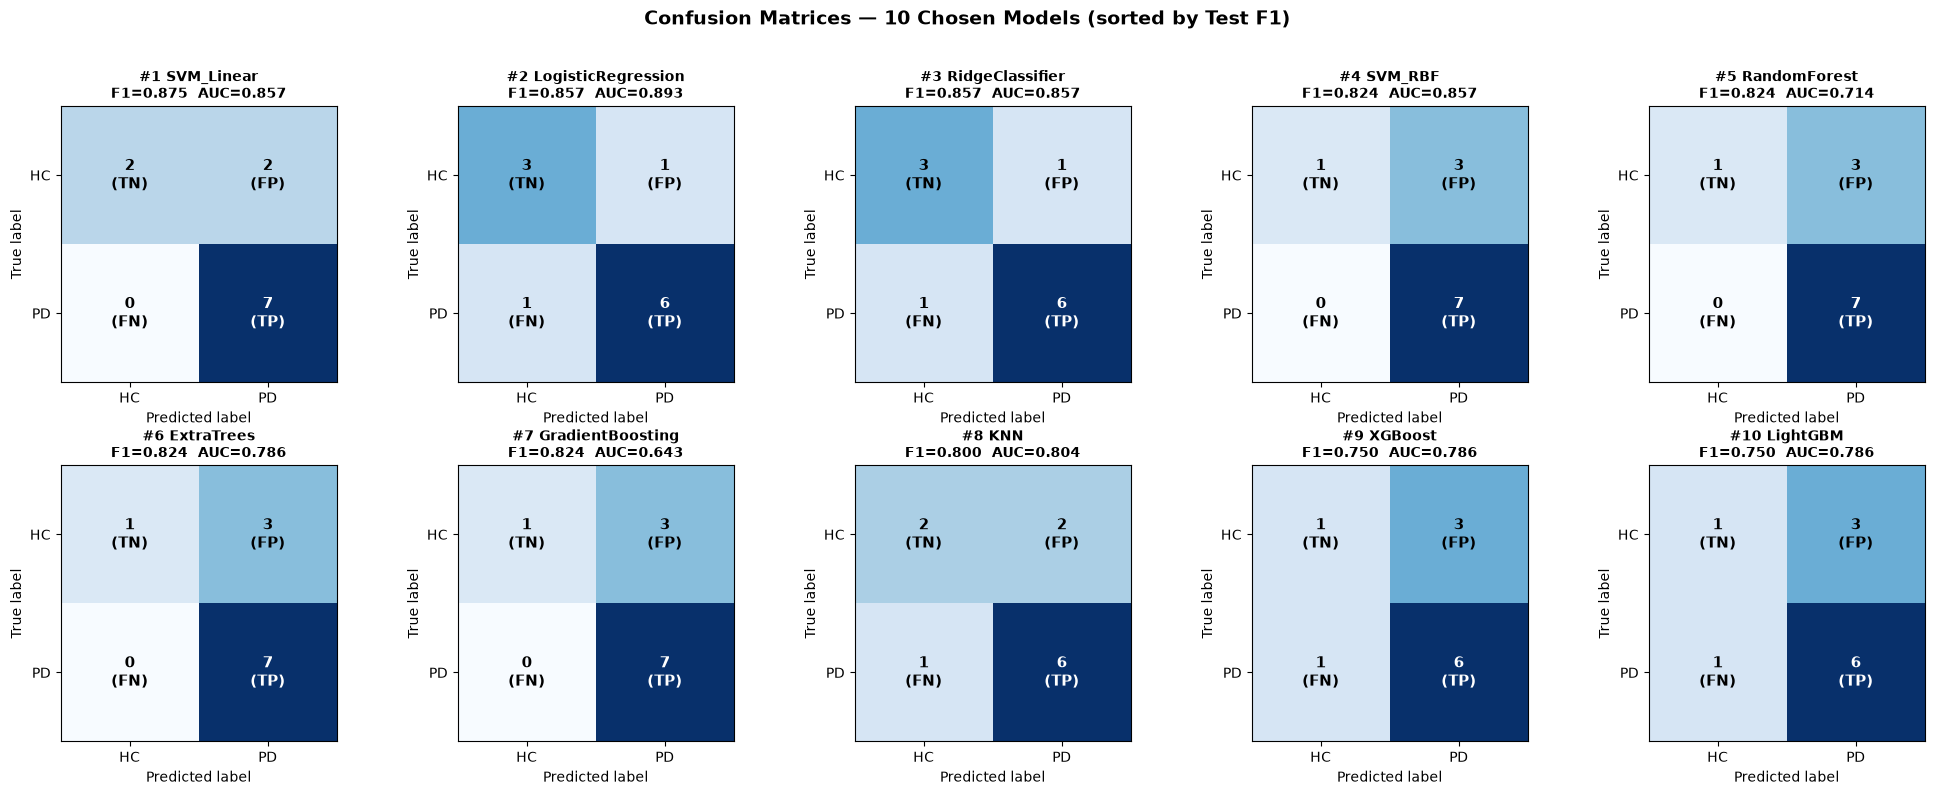

Saved: confusion_matrices_10models.png


In [5]:
"""
Plots the confusion matrix for each of the 10 chosen models, in a grid,
sorted by test F1 (same order as the metrics dashboard and table)
"""

from sklearn.metrics import confusion_matrix

# sort models by F1, same order as the dashboard/table
rows = [{"Model": name, "test_f1": r["test_f1"]} for name, r in best_of.items()]
order = pd.DataFrame(rows).sort_values("test_f1", ascending=False)["Model"].tolist()

n_models = len(order)
n_cols = 5
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, name in enumerate(order):
    ax = axes[i]
    r = best_of[name]
    cm = confusion_matrix(y_test, r["_ypred"], labels=[0, 1])  # rows/cols: HC, PD

    ax.imshow(cm, cmap="Blues", vmin=0)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["HC", "PD"])
    ax.set_yticklabels(["HC", "PD"])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    labels = np.array([["TN", "FP"], ["FN", "TP"]])
    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for row in range(2):
        for col in range(2):
            color = "white" if cm[row, col] > thresh else "black"
            ax.text(col, row, f"{cm[row, col]}\n({labels[row, col]})",
                     ha="center", va="center", fontsize=11, fontweight="bold", color=color)

    ax.set_title(f"#{i+1} {name}\nF1={r['test_f1']:.3f}  AUC={r['test_auc']:.3f}",
                 fontsize=10, fontweight="bold")

# hide any unused subplot slots (grid may be bigger than n_models)
for j in range(n_models, len(axes)):
    axes[j].axis("off")

fig.suptitle("Confusion Matrices — 10 Chosen Models (sorted by Test F1)",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(FIGURES_DIR, "confusion_matrices_10models.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices_10models.png")

Top 20 connectivity features — SVM-Linear

#1   Frontal_Sup_Orb_R ↔ Olfactory_L               weight=-0.3272  -> HC
#2   Cingulum_Mid_R ↔ Vermis_1_2                   weight=-0.2986  -> HC
#3   Frontal_Inf_Orb_R ↔ Calcarine_L               weight=-0.2891  -> HC
#4   Frontal_Sup_Orb_R ↔ Occipital_Sup_R           weight=-0.2729  -> HC
#5   Frontal_Inf_Orb_L ↔ Cingulum_Post_L           weight=-0.2636  -> HC
#6   Calcarine_R ↔ Thalamus_L                      weight=+0.2459  -> PD
#7   Occipital_Mid_L ↔ Occipital_Inf_R             weight=-0.2235  -> HC
#8   Frontal_Mid_L ↔ Cerebelum_6_R                 weight=-0.2126  -> HC
#9   Putamen_R ↔ Vermis_6                          weight=-0.2098  -> HC
#10  Calcarine_R ↔ Postcentral_R                   weight=-0.2045  -> HC
#11  Cuneus_L ↔ Thalamus_L                         weight=+0.2020  -> PD
#12  Frontal_Mid_Orb_L ↔ Lingual_L                 weight=-0.1964  -> HC
#13  Calcarine_L ↔ Thalamus_L                      weight=+0.1867  -> PD
#14  Fro

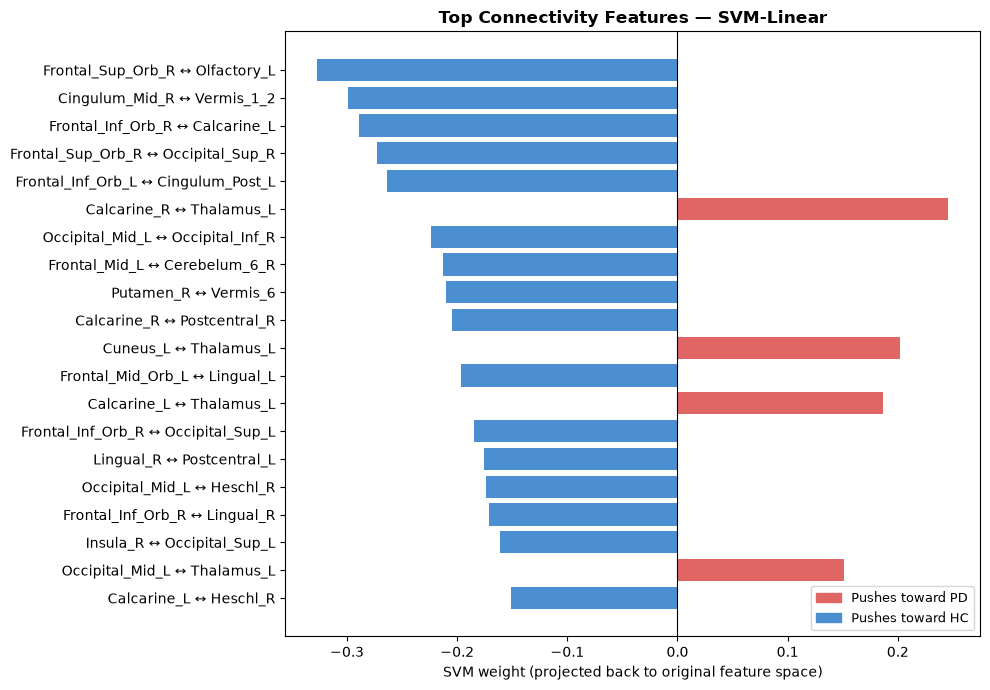

Saved: top_connectivity_features_svm_linear.png


In [7]:
"""
Shows which functional-connectivity features (brain region pairs) drive the
SVM-Linear model's predictions — the "what did it actually learn" question
that a metrics table alone can't answer

Traces SVM-Linear's coefficients back through PCA and SelectKBest to the
original 6,670 connectivity features, maps each surviving feature to its
AAL-116 region pair, and plots the top-N by |weight|. Positive weight =
pushes prediction toward PD; negative = pushes toward HC

"""

N_REGIONS = 116
TOP_N = 20

# Standard AAL-116 atlas region names (Tzourio-Mazoyer et al., 2002), 1-indexed
AAL_116_LABELS = {
    1: "Precentral_L", 2: "Precentral_R", 3: "Frontal_Sup_L", 4: "Frontal_Sup_R",
    5: "Frontal_Sup_Orb_L", 6: "Frontal_Sup_Orb_R", 7: "Frontal_Mid_L", 8: "Frontal_Mid_R",
    9: "Frontal_Mid_Orb_L", 10: "Frontal_Mid_Orb_R", 11: "Frontal_Inf_Oper_L", 12: "Frontal_Inf_Oper_R",
    13: "Frontal_Inf_Tri_L", 14: "Frontal_Inf_Tri_R", 15: "Frontal_Inf_Orb_L", 16: "Frontal_Inf_Orb_R",
    17: "Rolandic_Oper_L", 18: "Rolandic_Oper_R", 19: "Supp_Motor_Area_L", 20: "Supp_Motor_Area_R",
    21: "Olfactory_L", 22: "Olfactory_R", 23: "Frontal_Sup_Medial_L", 24: "Frontal_Sup_Medial_R",
    25: "Frontal_Med_Orb_L", 26: "Frontal_Med_Orb_R", 27: "Rectus_L", 28: "Rectus_R",
    29: "Insula_L", 30: "Insula_R", 31: "Cingulum_Ant_L", 32: "Cingulum_Ant_R",
    33: "Cingulum_Mid_L", 34: "Cingulum_Mid_R", 35: "Cingulum_Post_L", 36: "Cingulum_Post_R",
    37: "Hippocampus_L", 38: "Hippocampus_R", 39: "ParaHippocampal_L", 40: "ParaHippocampal_R",
    41: "Amygdala_L", 42: "Amygdala_R", 43: "Calcarine_L", 44: "Calcarine_R",
    45: "Cuneus_L", 46: "Cuneus_R", 47: "Lingual_L", 48: "Lingual_R",
    49: "Occipital_Sup_L", 50: "Occipital_Sup_R", 51: "Occipital_Mid_L", 52: "Occipital_Mid_R",
    53: "Occipital_Inf_L", 54: "Occipital_Inf_R", 55: "Fusiform_L", 56: "Fusiform_R",
    57: "Postcentral_L", 58: "Postcentral_R", 59: "Parietal_Sup_L", 60: "Parietal_Sup_R",
    61: "Parietal_Inf_L", 62: "Parietal_Inf_R", 63: "SupraMarginal_L", 64: "SupraMarginal_R",
    65: "Angular_L", 66: "Angular_R", 67: "Precuneus_L", 68: "Precuneus_R",
    69: "Paracentral_Lobule_L", 70: "Paracentral_Lobule_R", 71: "Caudate_L", 72: "Caudate_R",
    73: "Putamen_L", 74: "Putamen_R", 75: "Pallidum_L", 76: "Pallidum_R",
    77: "Thalamus_L", 78: "Thalamus_R", 79: "Heschl_L", 80: "Heschl_R",
    81: "Temporal_Sup_L", 82: "Temporal_Sup_R", 83: "Temporal_Pole_Sup_L", 84: "Temporal_Pole_Sup_R",
    85: "Temporal_Mid_L", 86: "Temporal_Mid_R", 87: "Temporal_Pole_Mid_L", 88: "Temporal_Pole_Mid_R",
    89: "Temporal_Inf_L", 90: "Temporal_Inf_R", 91: "Cerebelum_Crus1_L", 92: "Cerebelum_Crus1_R",
    93: "Cerebelum_Crus2_L", 94: "Cerebelum_Crus2_R", 95: "Cerebelum_3_L", 96: "Cerebelum_3_R",
    97: "Cerebelum_4_5_L", 98: "Cerebelum_4_5_R", 99: "Cerebelum_6_L", 100: "Cerebelum_6_R",
    101: "Cerebelum_7b_L", 102: "Cerebelum_7b_R", 103: "Cerebelum_8_L", 104: "Cerebelum_8_R",
    105: "Cerebelum_9_L", 106: "Cerebelum_9_R", 107: "Cerebelum_10_L", 108: "Cerebelum_10_R",
    109: "Vermis_1_2", 110: "Vermis_3", 111: "Vermis_4_5", 112: "Vermis_6",
    113: "Vermis_7", 114: "Vermis_8", 115: "Vermis_9", 116: "Vermis_10",
}


def get_top_connectivity_features(pipeline, top_n=TOP_N, n_regions=N_REGIONS):
    """Traces SVM-Linear coefficients back through PCA -> SelectKBest -> VarianceThreshold
    to the original connectivity feature indices, then to AAL region-pair names."""
    var_support = pipeline.named_steps["var"].get_support()          # bool mask over original 6670
    select_support = pipeline.named_steps["select"].get_support()    # bool mask over post-variance features
    svm = pipeline.named_steps["model"]

    orig_indices_after_var = np.where(var_support)[0]
    selected_orig_indices = orig_indices_after_var[select_support]   # indices into the original 6670 features

    if "pca" in pipeline.named_steps:
        pca = pipeline.named_steps["pca"]
        weights = svm.coef_[0] @ pca.components_                     # project back to selected-feature space
    else:
        weights = svm.coef_[0]

    # same upper-triangle order used when the feature matrix was built
    i_idx, j_idx = np.triu_indices(n_regions, k=1)

    order = np.argsort(-np.abs(weights))[:top_n]
    rows = []
    for rank, idx in enumerate(order, start=1):
        orig_feat_idx = selected_orig_indices[idx]
        r1, r2 = i_idx[orig_feat_idx] + 1, j_idx[orig_feat_idx] + 1   # back to 1-indexed AAL ids
        name1 = AAL_116_LABELS.get(r1, f"ROI_{r1}")
        name2 = AAL_116_LABELS.get(r2, f"ROI_{r2}")
        rows.append({
            "rank": rank,
            "region_pair": f"{name1} \u2194 {name2}",
            "weight": weights[idx],
        })
    return rows


def plot_top_features(rows, title="Top Connectivity Features \u2014 SVM-Linear"):
    labels = [r["region_pair"] for r in rows][::-1]
    weights = [r["weight"] for r in rows][::-1]
    colors = ["#E06666" if w > 0 else "#4C8FD1" for w in weights]

    fig, ax = plt.subplots(figsize=(10, max(6, 0.35 * len(rows))))
    ax.barh(labels, weights, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("SVM weight (projected back to original feature space)")
    ax.set_title(title, fontweight="bold")

    handles = [plt.Rectangle((0, 0), 1, 1, color="#E06666"), plt.Rectangle((0, 0), 1, 1, color="#4C8FD1")]
    ax.legend(handles, ["Pushes toward PD", "Pushes toward HC"], loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "top_connectivity_features_svm_linear.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: top_connectivity_features_svm_linear.png")


if __name__ == "__main__":
    pipeline = best_of["SVM_Linear"]["_model"]
    top_features = get_top_connectivity_features(pipeline, top_n=TOP_N)

    print(f"Top {TOP_N} connectivity features \u2014 SVM-Linear\n")
    for r in top_features:
        direction = "-> PD" if r["weight"] > 0 else "-> HC"
        print(f"#{r['rank']:<3} {r['region_pair']:<45} weight={r['weight']:+.4f}  {direction}")

    plot_top_features(top_features)